# Feature Engineering


1. Feature Engineering
2. Normalization Check
3. Building the DataLoader
4. Sanity Checks & Batch Inspection
5. Save Normalizer for Training

In [17]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader

# ── Paths ─────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path().resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parents[2]          # gnn_drone_project/
DATASETS_DIR  = PROJECT_ROOT / "datasets"
SRC_DIR       = NOTEBOOK_DIR.parent / "src"
RESULTS_DIR   = NOTEBOOK_DIR.parent / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME  = "setpoint_mixed_v1_mixed_formations"

TRAIN_PATH = DATASETS_DIR / f"{DATASET_NAME}_train.pt"
VAL_PATH   = DATASETS_DIR / f"{DATASET_NAME}_val.pt"
TEST_PATH  = DATASETS_DIR / f"{DATASET_NAME}_test.pt"
META_PATH  = DATASETS_DIR / f"{DATASET_NAME}_metadata.json"

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH, META_PATH]:
    print(f"{p.name}")

print(f"\nPyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

setpoint_mixed_v1_mixed_formations_train.pt
setpoint_mixed_v1_mixed_formations_val.pt
setpoint_mixed_v1_mixed_formations_test.pt
setpoint_mixed_v1_mixed_formations_metadata.json

PyTorch version : 2.7.1+cu118
CUDA available  : True


In [19]:
class DroneSwarmDataset(InMemoryDataset):
    """
    Loader for pre-built .pt split files from datacollection.py.

    Stored fields per Data graph:
      x            [N, 25]  – Raw node features (velocities + obstacles + formation)
      target       [N, 4]   – Expert setpoint error [Δx, Δy, Δz, Δyaw] → YOUR LABEL
      y            [N, 4]   – Motor PWM (NOT used — PID handles this)
      edge_index   [2, E]   – Directed communication graph
      edge_attr    [E, 3]   – Relative 3D position (pⱼ - pᵢ)
      pos          [N, 3]   – World-frame position (visualization only)
      formation_id [1]      – 0=A, 1=rectangle, 2=triangle
      episode_id   [1]
      step_idx     [1]
      num_drones   [1]
    """

    def __init__(self, split_path: str | Path):
        split_path = Path(split_path)
        if not split_path.exists():
            raise FileNotFoundError(f"Dataset file not found: {split_path}")

        payload = torch.load(split_path, weights_only=False)

        self.formation_names = payload.get("formation_names", ["a", "rectangle", "triangle"])
        self.split_name      = payload.get("split_name", "unknown")

        super().__init__(root="")

        self.data   = payload["data"]
        self.slices = payload["slices"]


# Load all three splits 
train_ds = DroneSwarmDataset(TRAIN_PATH)
val_ds   = DroneSwarmDataset(VAL_PATH)
test_ds  = DroneSwarmDataset(TEST_PATH)

print(f"\n{'Split':<10} {'Graphs':>8}")
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:<10} {len(ds):>8,}")


Split        Graphs
train        48,013
val           6,099
test          6,362


---
## 1. Feature Engineering

### Summary of decisions

| Step | What | Why |
|------|------|-----|
| **Sin/Cos Yaw** | Replace `ang_z` with `sin(yaw)` & `cos(yaw)` | Cyclic feature, avoids discontinuity at ±π |
| **Local Frame Δ** | Convert `Δx, Δy` to drone's body frame | Decouples setpoint from global orientation |
| **Drop dead cols** | Remove `x[:,6:22]` | Zero-variance (no obstacles in v1) |
| **Z-score features** | All continuous inputs | Similar scale → faster convergence |
| **Keep one-hot {0,1}** | Formation bits pass through | GNN uses as categorical switch |
| **Z-score labels** | Local frame setpoint errors | Prevents gradient explosion |
| **Add distance to edges** | 4th edge feature √(Δx²+Δy²+Δz²) | Helps GATv2 attention |
| **Z-score edge_attr** | All 4 edge dims | Consistent scale |

> Stats computed on **TRAIN set only**, applied to all splits.
> Labels are denormalized at inference: `setpoint = denormalize_target(pred, yaw)`


In [ ]:
import math

def wrap_angle(angle: torch.Tensor) -> torch.Tensor:
    """Wrap angle to [-pi, pi]."""
    return (angle + math.pi) % (2 * math.pi) - math.pi

# The raw data contains ang_z at index 5, which we will process.
# The final input to the GNN will have 10 features.
X_KEEP_INDICES = [0, 1, 2, 3, 4, 5, 22, 23, 24]

INPUT_NAMES = [
    "vel_x", "vel_y", "vel_z",
    "ang_x", "ang_y",
    "sin_yaw", "cos_yaw",
    "form_a", "form_rect", "form_tri",
]
LABEL_NAMES = ["Δx_local", "Δy_local", "Δz", "Δyaw"]
EDGE_NAMES  = ["rel_x", "rel_y", "rel_z", "distance"]


In [ ]:
# ── 1.1  Compute normalization statistics (TRAIN SET ONLY) ──────────────────

# --- Process Inputs (x) ---
raw_x_selected = train_ds._data.x[:, X_KEEP_INDICES]
yaw = wrap_angle(raw_x_selected[:, 5])
sin_yaw = torch.sin(yaw).unsqueeze(1)
cos_yaw = torch.cos(yaw).unsqueeze(1)
# Replace yaw with sin/cos representation
raw_x_transformed = torch.cat([raw_x_selected[:, :5], sin_yaw, cos_yaw, raw_x_selected[:, 6:]], dim=1)

x_mean = raw_x_transformed.mean(0)
x_std  = raw_x_transformed.std(0).clamp(min=1e-6)
x_mean[-3:] = 0.0  # one-hot pass-through
x_std[-3:]  = 1.0

# --- Process Targets (y) ---
raw_target = train_ds._data.target
delta_x, delta_y = raw_target[:, 0], raw_target[:, 1]
# Note: yaw is from the *input* features, representing the drone's current state
current_yaw = wrap_angle(train_ds._data.x[:, 5])
x_local = delta_x * torch.cos(current_yaw) + delta_y * torch.sin(current_yaw)
y_local = -delta_x * torch.sin(current_yaw) + delta_y * torch.cos(current_yaw)
raw_target_local = torch.stack([x_local, y_local, raw_target[:, 2], wrap_angle(raw_target[:, 3])], dim=1)

target_mean = raw_target_local.mean(0)
target_std  = raw_target_local.std(0).clamp(min=1e-6)

# --- Process Edges (e) ---
raw_edge_attr = train_ds._data.edge_attr
raw_edge_dist = torch.norm(raw_edge_attr, dim=1, keepdim=True)
raw_edge_full = torch.cat([raw_edge_attr, raw_edge_dist], dim=1)
edge_mean = torch.zeros(4)
edge_std  = raw_edge_full.std(dim=0).clamp(min=1e-6)


print("=" * 65)
print("NORMALIZATION STATISTICS (from train set)")
print("=" * 65)

print("\n  INPUT (x):")
print(f"  {'Name':<12} {'mean':>8} {'std':>8}  {'norm':>12}")
for i, (name, mu, sg) in enumerate(zip(INPUT_NAMES, x_mean.tolist(), x_std.tolist())):
    norm = "pass-through" if i >= 7 else "z-score"
    print(f"  {name:<12} {mu:>8.4f} {sg:>8.4f}  {norm:>12}")

print("\n  LABEL (setpoint error):")
print(f"  {'Name':<12} {'mean':>8} {'std':>8}")
for name, mu, sg in zip(LABEL_NAMES, target_mean.tolist(), target_std.tolist()):
    print(f"  {name:<12} {mu:>8.4f} {sg:>8.4f}")

print("\n  EDGE ATTR (4D):")
print(f"  {'Name':<12} {'mean':>8} {'std':>8}")
for name, mu, sg in zip(EDGE_NAMES, edge_mean.tolist(), edge_std.tolist()):
    print(f"  {name:<12} {mu:>8.4f} {sg:>8.4f}")


NORMALIZATION STATISTICS (from train set)

  INPUT (x):
  Name             mean      std          norm
  vel_x         -0.0017   0.8030       z-score
  vel_y          0.0014   0.8156       z-score
  vel_z         -0.0080   0.4662       z-score
  ang_x          0.0019   0.3376       z-score
  ang_y          0.0010   0.3198       z-score
  ang_z          0.0091   0.9950       z-score
  form_a         0.0000   1.0000  pass-through
  form_rect      0.0000   1.0000  pass-through
  form_tri       0.0000   1.0000  pass-through

  LABEL (setpoint error):
  Name             mean      std
  Δx             0.0069   2.3725
  Δy            -0.0157   2.3735
  Δz             0.3846   0.8292
  Δyaw           0.0056   0.6601

  EDGE ATTR (4D):
  Name             mean      std
  rel_x          0.0000   4.6453
  rel_y          0.0000   4.4536
  rel_z          0.0000   0.7824
  distance       0.0000   2.3831


In [ ]:
# ── 1.2  SetpointNormalizer ────────────────────────────────────────────────

class SetpointNormalizer:
    """
    Feature engineering for setpoint prediction.

    - Selects useful x columns (drops constant obstacle placeholders)
    - Replaces yaw with sin(yaw) and cos(yaw)
    - Z-score normalizes velocity & angular features
    - Leaves formation one-hot at {0, 1}
    - Transforms Δx, Δy labels to local body frame
    - Z-score normalizes setpoint labels
    - Adds Euclidean distance to edges → 4D
    - Z-score normalizes edge features

    At inference: real_setpoint = denormalize_target(model_output, original_yaw)
    """

    X_KEEP_COLS = [0, 1, 2, 3, 4, 5, 22, 23, 24]  # ang_z is at index 5
    N_ONEHOT    = 3

    def __init__(self, x_mean, x_std, target_mean, target_std, edge_mean, edge_std):
        self.x_mean      = x_mean       # [10]
        self.x_std       = x_std        # [10]
        self.target_mean = target_mean  # [4]
        self.target_std  = target_std   # [4]
        self.edge_mean   = edge_mean    # [4]
        self.edge_std    = edge_std     # [4]

    @classmethod
    def fit(cls, train_dataset: DroneSwarmDataset) -> "SetpointNormalizer":
        """Compute stats from train set. Call ONCE."""
        # Process inputs (x)
        raw_x_selected = train_dataset._data.x[:, cls.X_KEEP_COLS]
        yaw = wrap_angle(raw_x_selected[:, 5])
        sin_yaw = torch.sin(yaw).unsqueeze(1)
        cos_yaw = torch.cos(yaw).unsqueeze(1)
        raw_x_transformed = torch.cat([raw_x_selected[:, :5], sin_yaw, cos_yaw, raw_x_selected[:, 6:]], dim=1)

        xm = raw_x_transformed.mean(0); xs = raw_x_transformed.std(0).clamp(min=1e-6)
        xm[-cls.N_ONEHOT:] = 0.0
        xs[-cls.N_ONEHOT:] = 1.0

        # Process targets (y)
        raw_t = train_dataset._data.target
        delta_x, delta_y = raw_t[:, 0], raw_t[:, 1]
        current_yaw = wrap_angle(train_dataset._data.x[:, 5])
        x_local = delta_x * torch.cos(current_yaw) + delta_y * torch.sin(current_yaw)
        y_local = -delta_x * torch.sin(current_yaw) + delta_y * torch.cos(current_yaw)
        raw_t_local = torch.stack([x_local, y_local, raw_t[:, 2], wrap_angle(raw_t[:, 3])], dim=1)
        
        tm = raw_t_local.mean(0); ts = raw_t_local.std(0).clamp(min=1e-6)

        # Process edges (e)
        raw_e = train_dataset._data.edge_attr
        raw_dist = torch.norm(raw_e, dim=1, keepdim=True)
        raw_e_full = torch.cat([raw_e, raw_dist], dim=1)
        em = torch.zeros(4); es = raw_e_full.std(0).clamp(min=1e-6)

        return cls(xm, xs, tm, ts, em, es)

    def transform_graph(self, graph: Data) -> Data:
        """Raw graph → GNN-ready graph."""
        x_sel = graph.x[:, self.X_KEEP_COLS]
        
        yaw = wrap_angle(x_sel[:, 5])
        sin_yaw = torch.sin(yaw).unsqueeze(1)
        cos_yaw = torch.cos(yaw).unsqueeze(1)
        x_transformed = torch.cat([x_sel[:, :5], sin_yaw, cos_yaw, x_sel[:, 6:]], dim=1)
        x_norm = (x_transformed - self.x_mean) / self.x_std

        delta_x, delta_y = graph.target[:, 0], graph.target[:, 1]
        current_yaw = wrap_angle(graph.x[:, 5])
        x_local = delta_x * torch.cos(current_yaw) + delta_y * torch.sin(current_yaw)
        y_local = -delta_x * torch.sin(current_yaw) + delta_y * torch.cos(current_yaw)
        y_local_transformed = torch.stack([x_local, y_local, graph.target[:, 2], wrap_angle(graph.target[:, 3])], dim=1)
        y_norm = (y_local_transformed - self.target_mean) / self.target_std

        dist = torch.norm(graph.edge_attr, dim=1, keepdim=True)
        edge_full = torch.cat([graph.edge_attr, dist], dim=1)
        e_norm = (edge_full - self.edge_mean) / self.edge_std

        return Data(
            x=x_norm,
            y=y_norm,
            edge_index=graph.edge_index,
            edge_attr=e_norm,
            pos=graph.pos,
            original_yaw=current_yaw.unsqueeze(1),
            formation_id=graph.formation_id,
            episode_id=graph.episode_id,
            step_idx=graph.step_idx,
            num_drones=graph.num_drones,
        )

    def denormalize_target(self, y_norm: torch.Tensor, original_yaw: torch.Tensor) -> torch.Tensor:
        """
        Convert normalized predictions → physical setpoints (metres/radians).
        Performs the inverse transform from local to global frame.
        """
        y_physical_local = y_norm * self.target_std + self.target_mean
        
        x_local, y_local = y_physical_local[:, 0], y_physical_local[:, 1]
        
        if original_yaw.dim() == 2 and original_yaw.shape[1] == 1:
            original_yaw = original_yaw.squeeze(1)

        cos_yaw = torch.cos(original_yaw)
        sin_yaw = torch.sin(original_yaw)

        delta_x_global = x_local * cos_yaw - y_local * sin_yaw
        delta_y_global = x_local * sin_yaw + y_local * cos_yaw
        
        return torch.stack([
            delta_x_global,
            delta_y_global,
            y_physical_local[:, 2],
            y_physical_local[:, 3]
        ], dim=1)

    # ── Serialization ──────────────────────────────────────────────────────
    def to_dict(self):
        return {
            "x_keep_cols":    self.X_KEEP_COLS,
            "x_mean":         self.x_mean.tolist(),
            "x_std":          self.x_std.tolist(),
            "target_mean":    self.target_mean.tolist(),
            "target_std":     self.target_std.tolist(),
            "edge_mean":      self.edge_mean.tolist(),
            "edge_std":       self.edge_std.tolist(),
            "input_names":    INPUT_NAMES,
            "label_names":    LABEL_NAMES,
            "edge_names":     EDGE_NAMES,
            "input_dim":      len(INPUT_NAMES),
            "output_dim":     len(LABEL_NAMES),
            "edge_dim":       len(EDGE_NAMES),
        }

    @classmethod
    def from_dict(cls, d):
        return cls(
            x_mean      = torch.tensor(d["x_mean"]),
            x_std       = torch.tensor(d["x_std"]),
            target_mean = torch.tensor(d["target_mean"]),
            target_std  = torch.tensor(d["target_std"]),
            edge_mean   = torch.tensor(d["edge_mean"]),
            edge_std    = torch.tensor(d["edge_std"]),
        )

    @classmethod
    def load(cls, path):
        with open(path) as f:
            return cls.from_dict(json.load(f))

    def save(self, path):
        with open(path, "w") as f:
            json.dump(self.to_dict(), f, indent=2)
        print(f"✅ Normalizer saved → {path}")


# ── Fit ──
normalizer = SetpointNormalizer.fit(train_ds)
print("SetpointNormalizer fitted ✅")
print(f"  Input dim  : {len(INPUT_NAMES)}   (velocities + sin/cos yaw + formation)")
print(f"  Label dim  : {len(LABEL_NAMES)}   (local frame setpoint error, z-scored)")
print(f"  Edge dim   : {len(EDGE_NAMES)}   (rel_xyz + distance)")


SetpointNormalizer fitted ✅
  Input dim  : 9   (velocities + formation)
  Label dim  : 4   (setpoint error, z-scored)
  Edge dim   : 4   (rel_xyz + distance)


In [ ]:
# ── 1.3  Verify transform ──────────────────────────────────────────────────
g_raw  = train_ds[0]
g_norm = normalizer.transform_graph(g_raw)

print("BEFORE:")
print(f"  x shape      : {tuple(g_raw.x.shape)}   (25-dim raw)")
print(f"  target       : {tuple(g_raw.target.shape)} (raw global setpoint)")
print(f"  edge_attr    : {tuple(g_raw.edge_attr.shape)} (3D raw)")

print("\nAFTER:")
print(f"  x (input)    : {tuple(g_norm.x.shape)}   (10-dim, sin/cos yaw)")
print(f"  y (label)    : {tuple(g_norm.y.shape)}   (4-dim, local frame z-scored)")
print(f"  edge_attr    : {tuple(g_norm.edge_attr.shape)} (4D with distance)")
print(f"  original_yaw : {tuple(g_norm.original_yaw.shape)}")
print()

print("Drone 0 input (10 features):")
for i, (name, val) in enumerate(zip(INPUT_NAMES, g_norm.x[0].numpy())):
    note = " ← {0,1} unchanged" if i >= 7 else ""
    print(f"  [{i}] {name:<12} = {val:>8.4f}{note}")

print(f"\nDrone 0 label (normalized local setpoint):")
for i, (name, val) in enumerate(zip(LABEL_NAMES, g_norm.y[0].numpy())):
    print(f"  [{i}] {name:<12} = {val:>8.4f}")

print(f"\nDenormalize round-trip check (local -> global):")
# We need the original yaw from the normalized graph to do the inverse transform
recovered_global = normalizer.denormalize_target(g_norm.y[0].unsqueeze(0), g_norm.original_yaw[0].unsqueeze(0))
original_global  = g_raw.target[0]
err = (recovered_global.squeeze(0) - original_global).abs().max().item()
print(f"  Original (Global):  {original_global.numpy().round(4)}")
print(f"  Recovered (Global): {recovered_global.squeeze(0).numpy().round(4)}")
print(f"  Max error: {err:.2e}  {'✅' if err < 1e-5 else '❌'}")


BEFORE:
  x shape      : (17, 25)   (25-dim raw)
  target       : (17, 4) (raw setpoint)
  edge_attr    : (128, 3) (3D raw)

AFTER:
  x (input)    : (17, 9)   (9-dim, no target in input!)
  y (label)    : (17, 4)   (4-dim, z-scored setpoint)
  edge_attr    : (128, 4) (4D with distance)

Drone 0 input (9 features):
  [0] vel_x        =   0.0021
  [1] vel_y        =  -0.0017
  [2] vel_z        =   0.0172
  [3] ang_x        =  -0.0055
  [4] ang_y        =  -0.0031
  [5] ang_z        =  -0.0091
  [6] form_a       =   1.0000 ← {0,1} unchanged
  [7] form_rect    =   0.0000 ← {0,1} unchanged
  [8] form_tri     =   0.0000 ← {0,1} unchanged

Drone 0 label (normalized setpoint):
  [0] Δx     =   1.9314
  [1] Δy     =   1.8134
  [2] Δz     =  -1.8241
  [3] Δyaw   =   3.0360

Denormalize round-trip check:
  Original:  [ 4.5891  4.2884 -1.128   2.0098]
  Recovered: [ 4.5891  4.2884 -1.128   2.0098]
  Max error: 0.00e+00  ✅


---
## 2. Normalisation Check

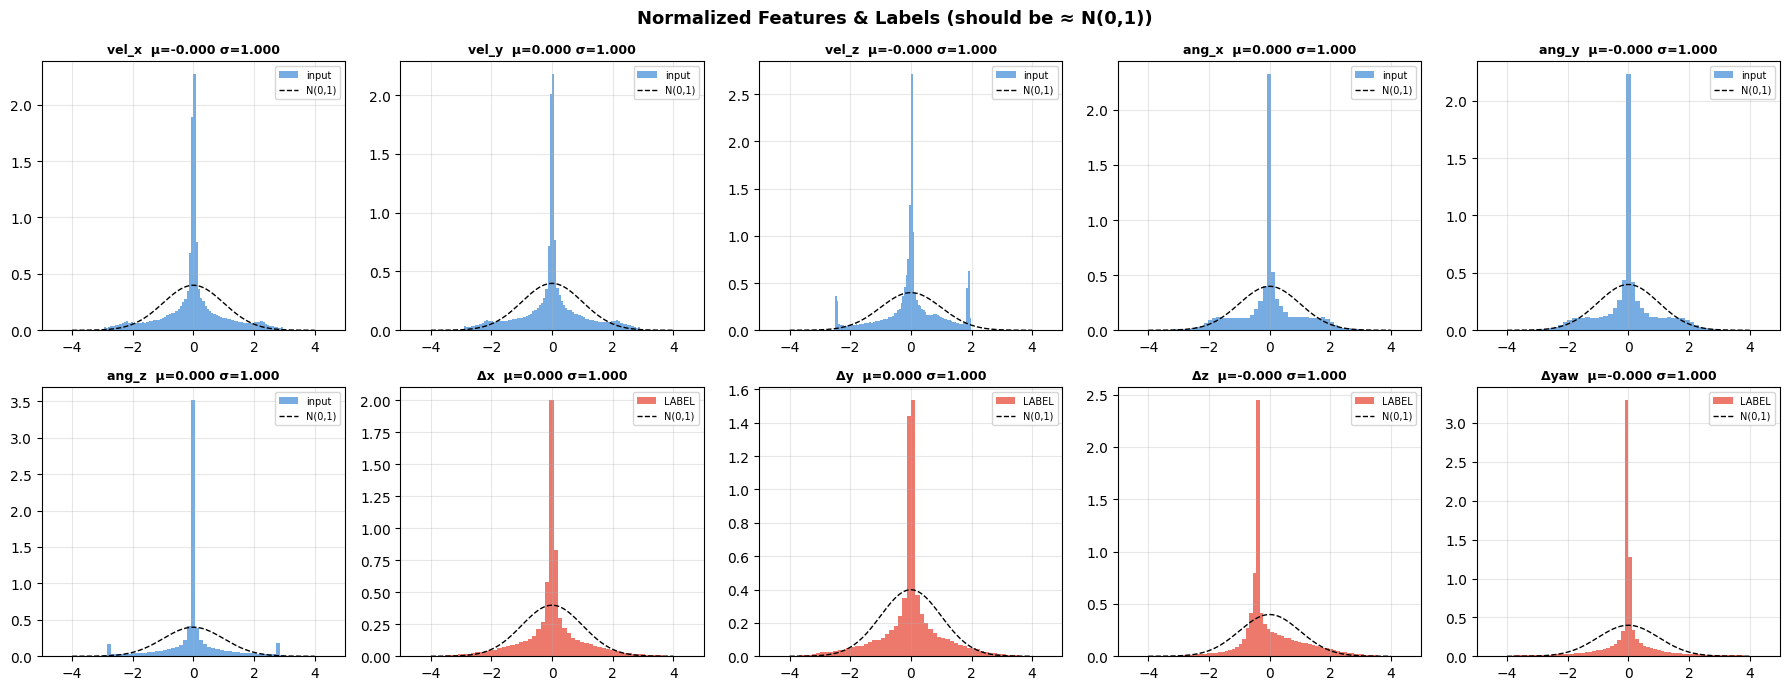

In [11]:
# ── Check that continuous input features & labels → ≈ N(0,1) ───────────────
normed_x = (raw_x_kept - normalizer.x_mean) / normalizer.x_std
normed_t = (raw_target - normalizer.target_mean) / normalizer.target_std

# Plot velocity/angular inputs (6) + setpoint labels (4) = 10 plots
cont_data  = torch.cat([normed_x[:, :6], normed_t], dim=1).numpy()  # [N, 10]
cont_names = INPUT_NAMES[:6] + LABEL_NAMES

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Normalized Features & Labels (should be ≈ N(0,1))",
             fontsize=13, fontweight="bold")

from scipy.stats import norm as scipy_norm
x_vals = np.linspace(-4, 4, 200)

for ax, i in zip(axes.flat, range(len(cont_names))):
    col = cont_data[:, i]
    color = "#4a90d9" if i < 6 else "#e74c3c"
    label_prefix = "input" if i < 6 else "LABEL"
    ax.hist(col, bins=80, density=True, color=color, alpha=0.75, label=label_prefix)
    ax.plot(x_vals, scipy_norm.pdf(x_vals), "k--", lw=1, label="N(0,1)")
    ax.set_title(f"{cont_names[i]}  μ={col.mean():.3f} σ={col.std():.3f}",
                 fontweight="bold", fontsize=9)
    ax.set_xlim(-5, 5)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "normalized_check.png", dpi=120)
plt.show()

---
## 3. Building the DataLoaders

```
Batch of 4 graphs:  [G1(15 drones), G2(12 drones), G3(18 drones), G4(10 drones)]

batch.x            → [55, 10]   concatenated input features (with sin/cos yaw)
batch.y            → [55, 4]    concatenated normalized LOCAL FRAME setpoint labels
batch.edge_index   → [2, E_sum] re-indexed edges
batch.edge_attr    → [E_sum, 4] concatenated edge features
batch.batch        → [55]       node-to-graph assignment
batch.original_yaw → [55, 1]    needed for denormalization
```


In [ ]:
# Import the updated get_dataloaders from our source file
sys.path.insert(0, str(SRC_DIR))
from dataset import get_dataloaders, SetpointNormalizer

# Get DataLoaders
train_loader, val_loader, test_loader, normalizer = get_dataloaders(
    dataset_dir=DATASETS_DIR,
    dataset_name="setpoint_mixed_v1_mixed_formations",
    batch_size=32,
    num_workers=0, # Must be 0 on Windows
)

# Save the normalizer for `train.py` and `evaluate.py`
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)
normalizer.save(results_dir / "normalizer.json")

print("Input features:", normalizer.to_dict()["input_names"])
print("Input dimension:", normalizer.to_dict()["input_dim"])
print("Label names:", normalizer.to_dict()["label_names"])
print("Output dimension:", normalizer.to_dict()["output_dim"])

DataLoaders created:
  train :  1501 batches  (bs=32)
  val   :    96 batches  (bs=64)
  test  :   100 batches  (bs=64)


---
## 4. Sanity Checks & Batch Inspection

In [ ]:
batch = next(iter(train_loader))


print("BATCH INSPECTION")
print(f"Graphs in batch    : {batch.num_graphs}")
print(f"Total nodes        : {batch.x.shape[0]}")
print(f"x shape (INPUT)    : {tuple(batch.x.shape)}    ← [nodes, 10]")
print(f"y shape (LABEL)    : {tuple(batch.y.shape)}    ← [nodes, 4] normalized LOCAL setpoint")
print(f"edge_index         : {tuple(batch.edge_index.shape)}")
print(f"edge_attr          : {tuple(batch.edge_attr.shape)}  ← [edges, 4]")
print(f"batch vector       : {tuple(batch.batch.shape)}")
print(f"original_yaw       : {tuple(batch.original_yaw.shape)}")
print()

print("Input — vel/ang/sincos (cols 0-6), should be ≈ N(0,1):")
print(f"  mean: {batch.x[:, :7].mean(0).numpy().round(3)}")
print(f"  std : {batch.x[:, :7].std(0).numpy().round(3)}")
print()
print("Input — formation one-hot (cols 7-9), should be {0, 1}:")
print(f"  unique: {[sorted(batch.x[:, i].unique().tolist()) for i in [7,8,9]]}")
print()
print("Label — local setpoint (cols 0-3), should be ≈ N(0,1):")
print(f"  mean: {batch.y.mean(0).numpy().round(3)}")
print(f"  std : {batch.y.std(0).numpy().round(3)}")


BATCH INSPECTION
Graphs in batch    : 32
Total nodes        : 454
x shape (INPUT)    : (454, 9)    ← [nodes, 9]
y shape (LABEL)    : (454, 4)    ← [nodes, 4] normalized setpoint
edge_index         : (2, 3912)
edge_attr          : (3912, 4)  ← [edges, 4]
batch vector       : (454,)

Input — velocity/angular (cols 0-5), should be ≈ N(0,1):
  mean: [ 0.03   0.007  0.023  0.016 -0.051 -0.005]
  std : [0.941 1.053 0.961 1.125 1.117 1.15 ]

Input — formation one-hot (cols 6-8), should be {0, 1}:
  unique: [[0.0, 1.0], [0.0, 1.0], [0.0, 1.0]]

Label — setpoint (cols 0-3), should be ≈ N(0,1):
  mean: [-0.049 -0.008 -0.095 -0.004]
  std : [0.975 1.086 1.055 1.339]


In [ ]:
# ── Mock forward pass ──────────────────────────────────────────────────────
IN_DIM   = 10   # state with sin/cos yaw
EDGE_DIM = 4    # rel_xyz + distance
OUT_DIM  = 4    # LOCAL setpoint [Δx_local, Δy_local, Δz, Δyaw]

dummy_model = torch.nn.Sequential(
    torch.nn.Linear(IN_DIM, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, OUT_DIM),
)

with torch.no_grad():
    pred_norm = dummy_model(batch.x)

loss = torch.nn.MSELoss()(pred_norm, batch.y)

# Denormalize to get real-world GLOBAL setpoints
pred_real_global = normalizer.denormalize_target(pred_norm[:3], batch.original_yaw[:3])

print("Mock forward pass:")
print(f"  Input  batch.x         : {tuple(batch.x.shape)}   (10-dim state)")
print(f"  Edges  batch.edge_attr : {tuple(batch.edge_attr.shape)}   (4-dim)")
print(f"  Output pred (local)    : {tuple(pred_norm.shape)}")
print(f"  Label  batch.y (local) : {tuple(batch.y.shape)}")
print(f"  MSE loss (normalized)  : {loss.item():.4f}")
print()
print("Denormalized predictions (first 3 nodes) — GLOBAL metres/radians:")
for i in range(3):
    print(f"  Node {i}: {pred_real_global[i].numpy().round(3)}")
print()
print("   Pipeline works!")
print("   GNN config: in_channels=10, edge_dim=4, out_channels=4")
print("   Final layer: Linear (NO Sigmoid — setpoints can be negative)")
print("   At inference: denormalize_target(pred, original_yaw) → feed to PID")


Mock forward pass:
  Input  batch.x         : (500, 9)   (9-dim state)
  Edges  batch.edge_attr : (4578, 4)   (4-dim)
  Output pred            : (500, 4)
  Label  batch.y         : (500, 4)
  MSE loss (normalized)  : 1.2748

Denormalized predictions (first 3 nodes) — real metres/radians:
  Node 0: [-0.737 -1.368  0.371 -0.035]
  Node 1: [-1.083 -0.068  0.291  0.163]
  Node 2: [-1.096  0.238  0.235  0.604]

✅ Pipeline works!
   GNN config: in_channels=9, edge_dim=4, out_channels=4
   Final layer: Linear (NO Sigmoid — setpoints can be negative)
   At inference: denormalize_target(pred) → feed to PID


In [15]:
# ── Throughput ──────────────────────────────────────────────────────────────
import time

total_nodes = 0
t0 = time.time()
for batch in train_loader:
    total_nodes += batch.x.shape[0]
elapsed = time.time() - t0

print(f"One full train epoch:")
print(f"  Total nodes : {total_nodes:,}")
print(f"  Time (CPU)  : {elapsed:.1f}s")
print(f"  Throughput  : {total_nodes / elapsed:,.0f} nodes/s")

One full train epoch:
  Total nodes : 699,876
  Time (CPU)  : 28.3s
  Throughput  : 24,724 nodes/s


---
## 5. Save Normalizer

In [ ]:
NORMALIZER_PATH = RESULTS_DIR / "normalizer.json"
normalizer.save(NORMALIZER_PATH)

# Verify round-trip
loaded = SetpointNormalizer.load(NORMALIZER_PATH)
assert torch.allclose(loaded.x_mean, normalizer.x_mean)
assert torch.allclose(loaded.target_std, normalizer.target_std)
assert torch.allclose(loaded.edge_std, normalizer.edge_std)
print(" Round-trip verified")
print(f" Saved to: {NORMALIZER_PATH}")

✅ Normalizer saved → C:\Users\aimen\Desktop\gnn_drone_project\gnn\setpoint_prediction\results\normalizer.json
✅ Round-trip verified
📁 Saved to: C:\Users\aimen\Desktop\gnn_drone_project\gnn\setpoint_prediction\results\normalizer.json


---
## Summary

### Data Contract

```
YOUR GNN INPUT ─────────────────────────────────────────────
    x = [vel_x, vel_y, vel_z,        ← z-scored
         ang_x, ang_y,               ← z-scored
         sin_yaw, cos_yaw,           ← z-scored
         form_a, form_rect, form_tri] ← {0,1} pass-through
                        = 10 dimensions

    edge_index = [2, E]
    edge_attr  = [E, 4]  ← [rel_x, rel_y, rel_z, distance] z-scored
                                    │
                    GNN message passing (GATv2)
                    learns WHERE to fly from neighbors
                                    │
                                    ▼
YOUR GNN OUTPUT ────────────────────────────────────────────
    pred = [Δx_local, Δy_local, Δz, Δyaw]   ← normalized (Linear, NO Sigmoid)
                                    │
                   denormalize_target(pred, original_yaw)
                                    │
                                    ▼
    real_setpoint_global = [2.1m, -0.5m, 0.3m, 0.12rad]
                                    │
                                    ▼
                   PID controller → motor PWM → drone flies
```

### Key numbers

| Property | Value |
|----------|-------|
| **Input dim** | 10 (velocities + sin/cos yaw + formation) |
| **Label dim** | 4  (LOCAL setpoint error, z-scored) |
| **Edge dim** | 4  (rel_xyz + distance) |
| **Train** | 48,013 graphs |
| **Val** | 6,099 graphs |
| **Test** | 6,362 graphs |
| **Drones/graph** | 10–20 |
| **Comm radius** | 10 m |

### How to use in `model.py`

```python
class SetpointGNN(torch.nn.Module):
    def __init__(self):
        # GATv2Conv(in_channels=10, out_channels=64, edge_dim=4)
        # Stack 3 layers
        # MLP head → Linear(hidden, 4)  ← NO Sigmoid!

    def forward(self, x, edge_index, edge_attr):
        # GATv2 message passing
        # MLP head
        return output  # normalized LOCAL setpoint, unbounded

# Training:
pred = model(batch.x, batch.edge_index, batch.edge_attr)
loss = MSELoss()(pred, batch.y)  # both in normalized LOCAL space

# Inference (feed to PID):
pred_norm = model(batch.x, batch.edge_index, batch.edge_attr)
setpoint_real_global = normalizer.denormalize_target(pred_norm, batch.original_yaw)
# setpoint_real_global is in metres/radians → send to PyFlyt PID
```

### Checklist ✅
- [x] Yaw encoded as sin/cos
- [x] Target labels transformed to local body frame
- [x] Target removed from input (no data leakage)
- [x] Label = setpoint error (not PWM)
- [x] Labels z-score normalized
- [x] Formation one-hot preserved at {0, 1}
- [x] Euclidean distance added to edges
- [x] No Sigmoid (setpoints can be negative)
- [x] `denormalize_target()` requires `original_yaw` for inference
- [x] Normalizer saved for train.py
